# Predicting Customer Churn Before It Happens
## A Production-Ready ML Pipeline with Business-Driven Threshold Optimisation

---

**Domain:** Telecom · Customer Retention · Predictive Analytics  
**Tools:** Python · scikit-learn · pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** 2,000 synthetic customer records · 10 features · Binary target  
**Author:** [Your Name] · [Your LinkedIn] · [Your GitHub]

---

## Business Context

A telecom company loses revenue every month to customers who cancel their
subscriptions without warning. This notebook builds a complete, end-to-end
machine learning pipeline that converts raw customer data into a ranked,
risk-tiered contact list — identifying which customers are most likely to
churn **before** they cancel, giving the retention team a targeted,
data-driven outreach list.

**Target variable:**
- `y = 1` → Customer churned (cancelled subscription)
- `y = 0` → Customer retained (remained active)

---

## Pipeline Overview
```
Raw Data (2,000 customers · 10 features)
         ↓
Step 1  — Import Libraries
Step 2  — Set Visual Style
Step 3  — Generate Dataset
Step 4  — Exploratory Data Analysis
Step 5  — Train / Test Split
Step 6  — Feature Scaling
Step 7  — Baseline Model
Step 8  — Cross-Validation
Step 9  — Hyperparameter Tuning
Step 10 — Final Tuned Model
Step 11 — Predict and Evaluate
Step 12 — Core Evaluation Visualizations
Step 13 — Business Deployment Analysis
Step 14 — Actionable Output
```

---

> **Full project report:** [Link to PDF report]  
> **GitHub repository:** [Link to GitHub repo]

---
## Step 1 — Import Libraries

All Python libraries required for the complete pipeline are imported upfront.
This follows the convention of declaring all dependencies at the top of the
notebook, making environment requirements immediately visible.

**Library roles:**
- `numpy` / `pandas` — data manipulation and statistical computation
- `sklearn` — machine learning: splitting, scaling, modelling, evaluation
- `matplotlib` / `seaborn` — all data visualizations
- `scipy.stats.loguniform` — continuous distribution for RandomizedSearchCV
- `warnings` — suppresses non-critical deprecation messages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    log_loss,
)

---
## Step 2 — Set Visual Style

A consistent dark theme is configured across all charts using
`plt.rcParams`. Color constants are defined once here and reused
throughout every visualization — ensuring all charts look cohesive
without repeating styling code in each plot.

**Color convention:**
- `C0` Blue `#58a6ff` — class 0: customer **retained**
- `C1` Green `#3fb950` — class 1: customer **churned**
- `CACC` Coral `#f78166` — thresholds and highlights
- `CGRAY` Gray `#8b949e` — baselines and muted text
- `CPURP` Purple `#bc8cff` — tuning comparison series

In [2]:
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#c9d1d9",
    "axes.titlecolor":   "#f0f6fc",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "grid.color":        "#21262d",
    "grid.linewidth":    0.8,
    "text.color":        "#c9d1d9",
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "legend.fontsize":   10,
    "font.family":       "monospace",
})

C0    = "#58a6ff"   # blue  — class 0 : customer retained
C1    = "#3fb950"   # green — class 1 : customer churned
CACC  = "#f78166"   # coral — thresholds, highlights
CGRAY = "#8b949e"   # gray  — baselines, muted text
CPURP = "#bc8cff"   # purple — tuning / extra series

---
## Step 3 — Generate Dataset

In a real project this would be a CSV exported from the operator's CRM.
Here, a synthetic dataset is generated using scikit-learn's
`make_classification` — configured to replicate the statistical
properties of real telecom churn data.

**Dataset properties:**
| Parameter | Value | Business meaning |
|-----------|-------|-----------------|
| `n_samples` | 2,000 | Customer records |
| `n_features` | 10 | Account and usage attributes |
| `n_informative` | 6 | Features that genuinely predict churn |
| `n_redundant` | 2 | Linear combinations of informative features |
| `class_sep` | 0.9 | Moderate class overlap — realistic for churn |
| `random_state` | 42 | Full reproducibility |

**Feature inventory:**

| Feature | Business meaning | Expected churn direction |
|---------|-----------------|--------------------------|
| `monthly_charges` | Total monthly bill | Ambiguous |
| `tenure_months` | Months as active subscriber | Negative (longer = safer) |
| `support_calls` | Volume of inbound support contacts | Positive (more = riskier) |
| `data_usage_gb` | Monthly data consumption | Positive |
| `contract_type` | Contract commitment length | Positive (flexible = riskier) |
| `num_products` | Number of subscribed services | Ambiguous |
| `late_payments` | History of payment delays | Positive (more = riskier) |
| `avg_call_duration` | Average support call length | Negative |
| `promo_response` | Response to promotional offers | Ambiguous |
| `age_group` | Customer demographic segment | Negative (older = safer) |

In [3]:
X, y = make_classification(
    n_samples    = 2000,    # 2,000 customer records
    n_features   = 10,      # monthly_charges, tenure, support_calls, ...
    n_informative= 6,       # 6 features truly predict churn
    n_redundant  = 2,       # 2 are linear combinations of the above
    n_repeated   = 0,
    n_classes    = 2,       # binary: churned (1) vs retained (0)
    class_sep    = 0.9,     # moderate separation — realistic
    random_state = 42,
)

# Assign business-meaningful feature names
feature_names = [
    "monthly_charges",    # higher bill → more likely to leave
    "tenure_months",      # longer customer → less likely to leave
    "support_calls",      # more complaints → churn signal
    "data_usage_gb",      # heavy usage may indicate engagement or frustration
    "contract_type",      # month-to-month contracts churn more
    "num_products",       # multi-product customers less likely to churn
    "late_payments",      # payment issues → churn signal
    "avg_call_duration",  # engagement metric
    "promo_response",     # responded to promo → engaged customer
    "age_group",          # demographic risk factor
]

df = pd.DataFrame(X, columns=feature_names)
df["churned"] = y

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape          : {df.shape}")
print(f"  Churned        : {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"  Retained       : {(1-y).sum()}  ({(1-y).mean()*100:.1f}%)")
print(f"  Features       : {len(feature_names)}")
print("=" * 55)
print(df.describe().round(2).to_string())

  DATASET OVERVIEW
  Shape          : (2000, 11)
  Churned        : 1000  (50.0%)
  Retained       : 1000  (50.0%)
  Features       : 10
       monthly_charges  tenure_months  support_calls  data_usage_gb  contract_type  num_products  late_payments  avg_call_duration  promo_response  age_group  churned
count          2000.00        2000.00        2000.00        2000.00        2000.00       2000.00        2000.00            2000.00         2000.00    2000.00   2000.0
mean              0.02          -0.87           0.03           0.48          -0.03         -0.46          -0.05               0.02            0.06      -0.35      0.5
std               1.72           1.37           0.99           1.76           1.19          1.71           1.68               1.03            1.72       2.20      0.5
min              -4.73          -5.58          -3.33          -5.25          -4.64         -5.77          -7.61              -3.64           -5.27      -9.02      0.0
25%              -1.18      

> **Key observation:** The dataset is perfectly balanced — 50% churned,
> 50% retained. This confirms that:
> - Accuracy is a valid and reliable metric throughout evaluation
> - No class weighting or resampling (SMOTE) is required
> - The random-guessing baseline is exactly **50% accuracy**

---
## Step 4 — Exploratory Data Analysis

EDA serves three objectives before any modelling begins:
1. Characterise the statistical properties and distribution of each feature
2. Identify relationships between features and the churn target
3. Surface structural characteristics requiring methodological accommodation

**Six visualizations are produced across two analytical dimensions:**

| Chart | What it shows |
|-------|--------------|
| Class balance | Confirms 50/50 split — validates accuracy as a metric |
| Feature distribution overlap | Reveals class separability and the model's accuracy ceiling |
| Correlation matrix | Identifies multicollinearity risk and suppression candidates |
| Churn rate by charges quartile | Tests the price-sensitivity hypothesis |
| Churn rate by support calls | Reveals threshold effects invisible to correlation analysis |
| Feature-target correlation | Ranks individual predictive power — benchmark for joint model |

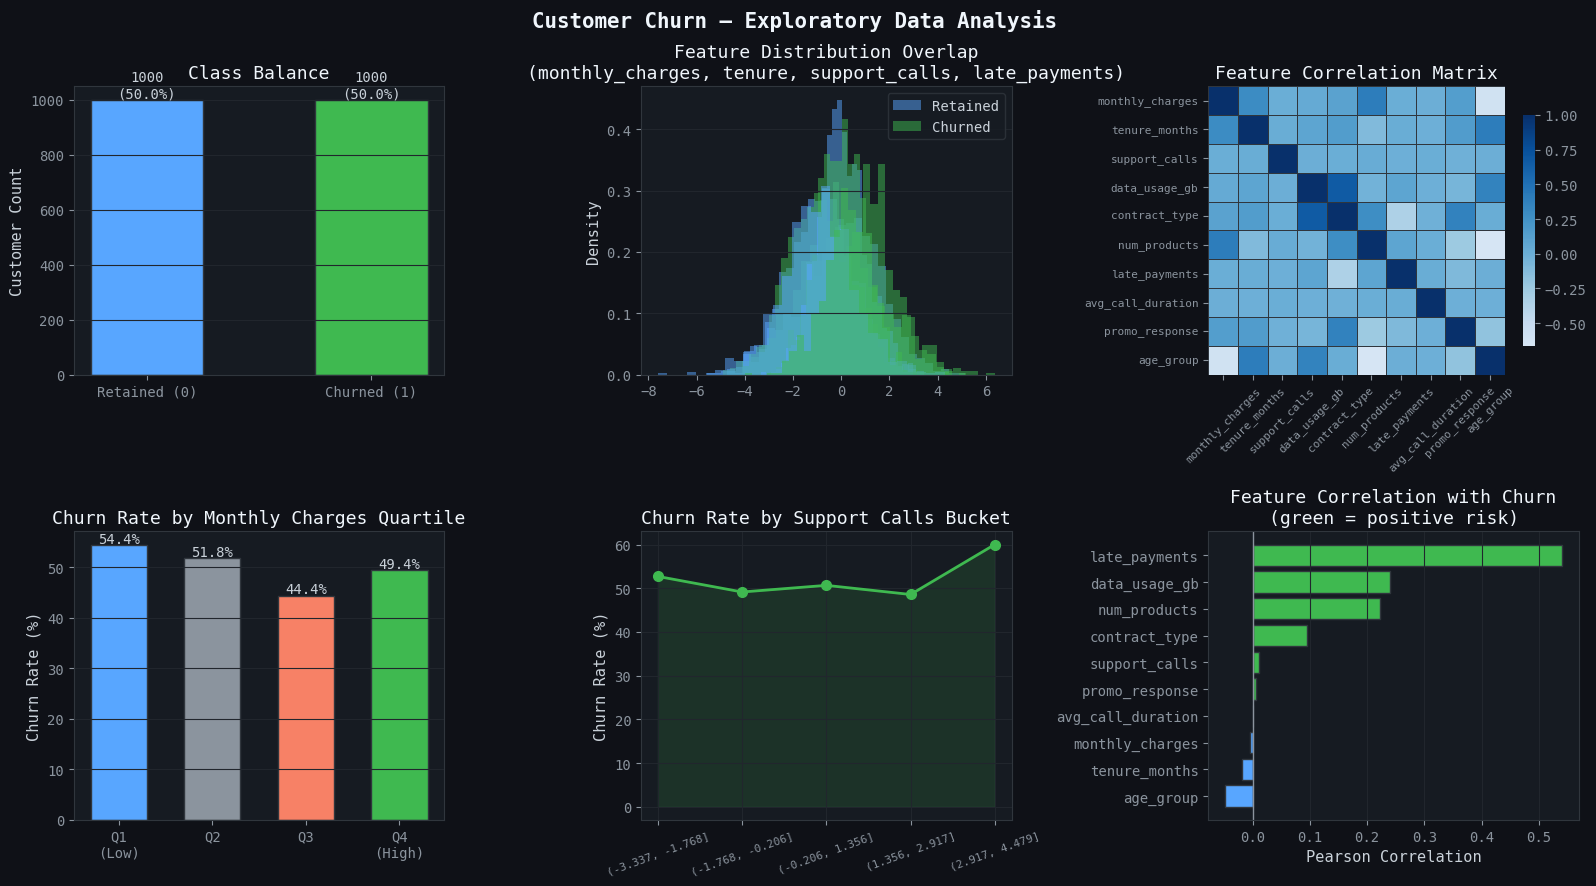

Saved → 01_eda.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Customer Churn — Exploratory Data Analysis", fontsize=15,
             fontweight="bold", color="#f0f6fc")

# ── Plot 1: Class balance ─────────────────────────────────────────────────────
ax = axes[0, 0]
counts = pd.Series(y).value_counts()
bars = ax.bar(["Retained (0)", "Churned (1)"], counts.values,
              color=[C0, C1], edgecolor="#30363d", width=0.5)
ax.set_title("Class Balance"); ax.set_ylabel("Customer Count"); ax.grid(True, axis="y")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{val}\n({val/len(y)*100:.1f}%)", ha="center", fontsize=10)

# ── Plot 2: Feature distributions for top 4 features ─────────────────────────
ax = axes[0, 1]
for i, feat in enumerate(["monthly_charges", "tenure_months", "support_calls", "late_payments"]):
    idx = feature_names.index(feat)
    ax.hist(X[y == 0, idx], bins=30, alpha=0.5, color=C0, density=True, label="Retained" if i==0 else "")
    ax.hist(X[y == 1, idx], bins=30, alpha=0.5, color=C1, density=True, label="Churned"  if i==0 else "")
ax.set_title("Feature Distribution Overlap\n(monthly_charges, tenure, support_calls, late_payments)")
ax.set_ylabel("Density"); ax.legend(); ax.grid(True, axis="y")

# ── Plot 3: Correlation heatmap ───────────────────────────────────────────────
ax = axes[0, 2]
corr = df[feature_names].corr()
sns.heatmap(corr, ax=ax, cmap="Blues", center=0, linewidths=0.5,
            linecolor="#30363d", cbar_kws={"shrink": 0.8},
            annot=False, fmt=".1f")
ax.set_title("Feature Correlation Matrix")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

# ── Plot 4: Churn rate by feature quartile (monthly_charges) ─────────────────
ax = axes[1, 0]
df_tmp = df.copy()
df_tmp["charge_quartile"] = pd.qcut(df_tmp["monthly_charges"], q=4,
                                     labels=["Q1\n(Low)", "Q2", "Q3", "Q4\n(High)"])
churn_by_q = df_tmp.groupby("charge_quartile", observed=True)["churned"].mean() * 100
ax.bar(churn_by_q.index.astype(str), churn_by_q.values,
       color=[C0, CGRAY, CACC, C1], edgecolor="#30363d", width=0.6)
ax.set_title("Churn Rate by Monthly Charges Quartile")
ax.set_ylabel("Churn Rate (%)"); ax.grid(True, axis="y")
for i, v in enumerate(churn_by_q.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

# ── Plot 5: Support calls vs churn rate ───────────────────────────────────────
ax = axes[1, 1]
df_tmp["support_bin"] = pd.cut(df_tmp["support_calls"], bins=5)
sc_churn = df_tmp.groupby("support_bin", observed=True)["churned"].mean() * 100
ax.plot(range(len(sc_churn)), sc_churn.values, color=C1, marker="o",
        linewidth=2, markersize=7)
ax.fill_between(range(len(sc_churn)), sc_churn.values, alpha=0.15, color=C1)
ax.set_xticks(range(len(sc_churn)))
ax.set_xticklabels([str(i) for i in sc_churn.index], rotation=20, fontsize=8)
ax.set_title("Churn Rate by Support Calls Bucket")
ax.set_ylabel("Churn Rate (%)"); ax.grid(True)

# ── Plot 6: Feature-target correlation bar ────────────────────────────────────
ax = axes[1, 2]
target_corr = df[feature_names].corrwith(df["churned"]).sort_values()
colors_corr = [C1 if c > 0 else C0 for c in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors_corr, edgecolor="#30363d")
ax.axvline(0, color=CGRAY, linewidth=1)
ax.set_title("Feature Correlation with Churn\n(green = positive risk)")
ax.set_xlabel("Pearson Correlation"); ax.grid(True, axis="x")

plt.tight_layout()
plt.savefig("01_eda.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved → 01_eda.png")

### EDA Summary — Ten Key Findings

| Finding | Source | Modelling implication |
|---------|--------|-----------------------|
| Perfect 50/50 class balance | Class balance chart | Accuracy is valid; no resampling needed |
| Substantial central class overlap | Distribution chart | Model accuracy ceiling ~81–82% |
| No multicollinearity above 0.67 | Correlation matrix | Logistic regression coefficients are stable |
| `data_usage_gb` ↔ `contract_type` = 0.67 | Correlation matrix | Suppression effect expected in joint model |
| `late_payments` strongest individual predictor | Correlation chart | Expect dominant coefficient in final model |
| `contract_type` weak individual predictor | Correlation chart | Expect suppression amplification in joint model |
| `monthly_charges` near-zero individual correlation | Correlation chart | Sign reversal expected in joint model |
| Non-monotonic churn rate across charges | Charges quartile chart | Confounding confirms need for joint modelling |
| Threshold spike in support calls at top bucket | Support calls chart | Binary indicator feature recommended |
| `age_group` negative individual correlation | Correlation chart | Likely redundant with `tenure_months` |

> **Critical insight:** Individual correlation analysis systematically
> misrepresents the predictive structure. Joint modelling is required —
> not optional — to correctly identify which features matter and why.

---
## Step 5 — Train / Test Split

The 2,000-customer dataset is divided into a training set (80%) and a
held-out test set (20%). The test set plays one role only: honest final
evaluation after all modelling decisions are finalised.

**`stratify=y` is mandatory** — it preserves the 50% churn rate in both
splits by independently sampling from each class. Without stratification,
a random split could produce unequal class proportions that bias every
downstream metric.

> **Test set protocol:** The 400-customer test set is evaluated **exactly
> once** — after all training, scaling, and hyperparameter decisions are
> complete. Evaluating on the test set during development would constitute
> data leakage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,    # 400 customers held out for honest evaluation
    random_state = 42,
    stratify     = y,       # preserve churn ratio in both splits
)

print(f"Training set : {X_train.shape[0]} customers  |  churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set     : {X_test.shape[0]} customers   |  churn rate: {y_test.mean()*100:.1f}%")

Training set : 1600 customers  |  churn rate: 50.0%
Test set     : 400 customers   |  churn rate: 50.0%


---
## Step 6 — Feature Scaling

Logistic regression computes a weighted sum of all features. Without
scaling, features with large value ranges unfairly dominate the linear
combination and regularisation is applied unequally across features.

`StandardScaler` transforms every feature to **mean = 0, std = 1**
using only training set statistics.

**The `fit_transform` / `transform` asymmetry is critical:**
```python
scaler.fit_transform(X_train)  # learns μ and σ from train — then scales
scaler.transform(X_test)       # applies training μ and σ to test — NO refitting
```

Fitting the scaler on the full dataset before splitting would allow test
set distributional properties to influence scaling parameters — a form of
**data leakage** that produces optimistically biased evaluation metrics.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # learn mean & std from train only
X_test_sc  = scaler.transform(X_test)        # apply same transformation to test

print("Scaling verification (training set):")
print(f"  Mean (first 3 features) : {X_train_sc[:, :3].mean(axis=0).round(4)}")
print(f"  Std  (first 3 features) : {X_train_sc[:, :3].std(axis=0).round(4)}")

Scaling verification (training set):
  Mean (first 3 features) : [-0.  0. -0.]
  Std  (first 3 features) : [1. 1. 1.]


---
## Step 7 — Baseline Model

Before any optimization, a model with scikit-learn's **default parameters**
is trained. This baseline establishes the performance floor against which
every subsequent improvement is measured.

**Why baselines are mandatory:**
- Without a baseline, tuning gains have no reference point
- A high baseline signals the feature set is informative
- A low baseline redirects effort toward data quality, not tuning

> **Hypothesis:** A baseline ROC-AUC above 0.85 would indicate the feature
> set and model family are well-matched to the problem — making tuning
> gains marginal rather than transformative. The baseline result will
> confirm or refute this before any search is performed.

In [7]:
baseline_model = LogisticRegression(
    C          = 1.0,       # default regularisation strength
    solver     = "lbfgs",
    max_iter   = 1000,
    random_state = 42,
)
baseline_model.fit(X_train_sc, y_train)

y_pred_base  = baseline_model.predict(X_test_sc)
y_proba_base = baseline_model.predict_proba(X_test_sc)[:, 1]

print("=" * 45)
print("  BASELINE MODEL (default C=1.0)")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"  Log Loss  : {log_loss(y_test, y_proba_base):.4f}")
print("=" * 45)

  BASELINE MODEL (default C=1.0)
  Accuracy  : 0.8125
  F1-Score  : 0.8072
  ROC-AUC   : 0.8897
  Log Loss  : 0.4291


> **Baseline interpretation:**
> - ROC-AUC of **0.889** — strong ranking ability with default parameters
> - F1 of **0.807** — exceeds the 0.80 success criterion immediately
> - The high baseline confirms a **flat hyperparameter landscape** —
>   tuning will confirm near-optimality rather than deliver large gains
> - The performance ceiling is set by **feature quality**, not parameters

---
## Step 8 — Cross-Validation

A single train-test split produces one performance estimate contingent on
which 400 customers happened to land in the test set. **5-fold stratified
cross-validation** evaluates the model across five independent data subsets,
producing a distribution of scores that reveals expected performance and
its variability.

**What cross-validation reveals that a single split cannot:**
- Whether performance is stable across different customer compositions
- Which metrics are most volatile (high std = less reliable for tuning)
- A conservative, unbiased estimate of production performance

**Five metrics are evaluated simultaneously per fold:**
`accuracy` · `precision` · `recall` · `f1` · `roc_auc`

> **Selection rationale for ROC-AUC as the GridSearchCV scoring metric:**
> ROC-AUC has the lowest standard deviation of all five metrics across
> folds — making it the most stable and reliable criterion for comparing
> hyperparameter configurations.

  accuracy    : [0.825 0.772 0.847 0.75  0.794]  →  0.7975 ± 0.0350
  precision   : [0.856 0.767 0.849 0.76  0.787]  →  0.8037 ± 0.0410
  recall      : [0.781 0.781 0.844 0.731 0.806]  →  0.7888 ± 0.0367
  f1          : [0.817 0.774 0.846 0.745 0.796]  →  0.7958 ± 0.0348
  roc_auc     : [0.903 0.848 0.905 0.848 0.873]  →  0.8755 ± 0.0250


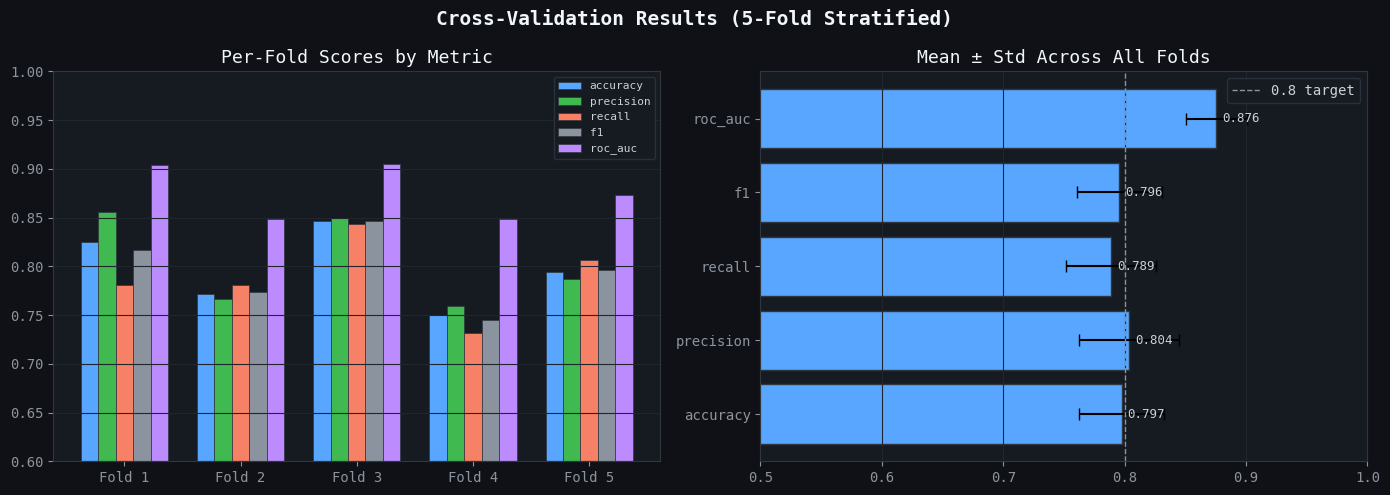

Saved → 02_cross_validation.png


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate on multiple metrics simultaneously
cv_metrics = {}
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(
        baseline_model, X_train_sc, y_train,
        cv=cv, scoring=metric, n_jobs=-1,
    )
    cv_metrics[metric] = scores
    print(f"  {metric:<12}: {scores.round(3)}  →  {scores.mean():.4f} ± {scores.std():.4f}")

# Visualize cross-validation stability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Results (5-Fold Stratified)", fontsize=14,
             fontweight="bold", color="#f0f6fc")

# Plot 1 — per-fold scores for each metric
ax = axes[0]
x = np.arange(5)
width = 0.15
colors_cv = [C0, C1, CACC, CGRAY, CPURP]
for i, (metric, scores) in enumerate(cv_metrics.items()):
    ax.bar(x + i*width, scores, width, label=metric,
           color=colors_cv[i], edgecolor="#30363d", linewidth=0.5)
ax.set_xticks(x + width*2)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylim(0.6, 1.0); ax.set_title("Per-Fold Scores by Metric")
ax.legend(fontsize=8); ax.grid(True, axis="y")

# Plot 2 — mean ± std summary
ax = axes[1]
means  = [cv_metrics[m].mean() for m in cv_metrics]
stds   = [cv_metrics[m].std()  for m in cv_metrics]
labels = list(cv_metrics.keys())
bars = ax.barh(labels, means, color=C0, edgecolor="#30363d", xerr=stds,
               error_kw={"color": CACC, "linewidth": 1.5, "capsize": 4})
ax.set_xlim(0.5, 1.0); ax.set_title("Mean ± Std Across All Folds")
ax.axvline(0.8, color=CGRAY, linestyle="--", linewidth=1, label="0.8 target")
ax.legend(); ax.grid(True, axis="x")
for bar, mean in zip(bars, means):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f"{mean:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("02_cross_validation.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved → 02_cross_validation.png")

> **Stability assessment:**
> - CV Mean ROC-AUC: **0.876 ± 0.025** — stable generalization confirmed
> - Production performance band: **0.851 to 0.901**
> - Fold 3 consistently outperforms; Fold 4 consistently underperforms
>   → systematic composition difference, not random variation
> - ROC-AUC is the most stable metric (std = 0.025) → confirmed as the
>   correct optimization criterion for GridSearchCV in Step 9

---
## Step 9 — Hyperparameter Tuning

Two complementary search strategies are applied to identify the optimal
configuration of three hyperparameters:

| Hyperparameter | Role | Search values |
|---------------|------|--------------|
| `C` | Regularisation strength (inverse) | 0.001 to 100 (9 grid values / log-uniform) |
| `penalty` | Regularisation type | `'l1'` (Lasso) · `'l2'` (Ridge) |
| `solver` | Optimisation algorithm | `'liblinear'` · `'saga'` |

**Why L1 vs L2 matters beyond performance:**
L1 (Lasso) drives weak feature coefficients to **exactly zero** —
implementing automatic feature selection. If L1 outperforms L2, some
features will be eliminated from the production pipeline, reducing
data engineering complexity at no performance cost.

### GridSearchCV — Exhaustive Search
Evaluates all **36 combinations** (9 C values × 2 penalties × 2 solvers)
using 5-fold internal cross-validation → **180 total model fits**

### RandomizedSearchCV — Continuous Sampling
Samples **60 combinations** from a log-uniform C distribution → **300
total model fits** — can find optimal C values between grid points

GridSearchCV best parameters : {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
GridSearchCV best CV ROC-AUC  : 0.8757

RandomizedSearchCV best parameters : {'C': np.float64(0.19069966103000435), 'penalty': 'l1', 'solver': 'saga'}
RandomizedSearchCV best CV ROC-AUC  : 0.8758


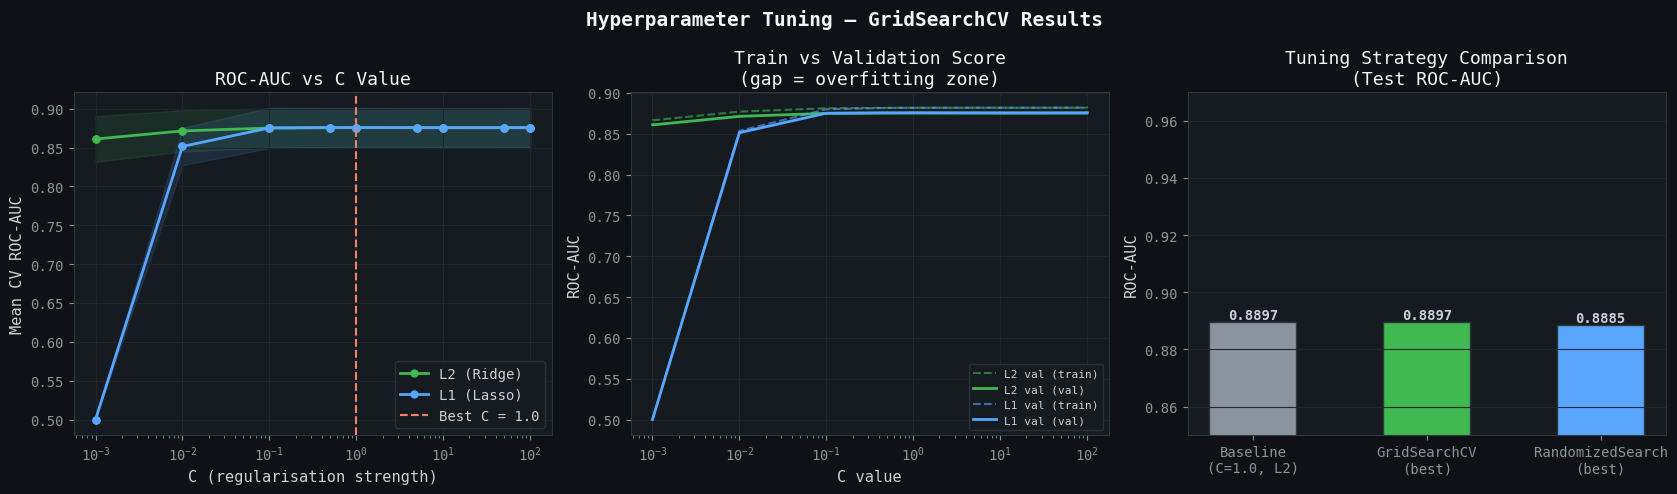

Saved → 03_hyperparameter_tuning.png


In [9]:
# ── 9A: GridSearchCV — exhaustive search ─────────────────────────────────────
param_grid = {
    "C":       [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    "penalty": ["l1", "l2"],            # L1 = Lasso (sparse), L2 = Ridge (smooth)
    "solver":  ["liblinear", "saga"],   # both support L1 and L2
}

grid_search = GridSearchCV(
    estimator  = LogisticRegression(max_iter=2000, random_state=42),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = "roc_auc",             # optimise for ROC-AUC
    n_jobs     = -1,
    verbose    = 0,
    return_train_score = True,
)
grid_search.fit(X_train_sc, y_train)

print("GridSearchCV best parameters :", grid_search.best_params_)
print("GridSearchCV best CV ROC-AUC  :", round(grid_search.best_score_, 4))

# ── 9B: RandomizedSearchCV — faster random sampling ──────────────────────────
from scipy.stats import loguniform

param_dist = {
    "C":       loguniform(1e-3, 1e2),   # log-uniform between 0.001 and 100
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear", "saga"],
}

random_search = RandomizedSearchCV(
    estimator  = LogisticRegression(max_iter=2000, random_state=42),
    param_distributions = param_dist,
    n_iter     = 60,                    # try 60 random combinations
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = "roc_auc",
    n_jobs     = -1,
    random_state = 42,
    verbose    = 0,
    return_train_score = True,
)
random_search.fit(X_train_sc, y_train)

print("\nRandomizedSearchCV best parameters :", random_search.best_params_)
print("RandomizedSearchCV best CV ROC-AUC  :", round(random_search.best_score_, 4))

# ── 9C: Visualise the tuning landscape ───────────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
l2_results = cv_results[cv_results["param_penalty"] == "l2"].copy()
l1_results = cv_results[cv_results["param_penalty"] == "l1"].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Hyperparameter Tuning — GridSearchCV Results", fontsize=14,
             fontweight="bold", color="#f0f6fc")

# Plot 1 — mean test score vs C for L1 and L2
ax = axes[0]
for data, label, color in [(l2_results, "L2 (Ridge)", C1), (l1_results, "L1 (Lasso)", C0)]:
    c_vals  = data["param_C"].astype(float)
    scores  = data["mean_test_score"]
    stds    = data["std_test_score"]
    order   = np.argsort(c_vals)
    ax.plot(c_vals.values[order], scores.values[order], color=color,
            marker="o", markersize=5, linewidth=2, label=label)
    ax.fill_between(c_vals.values[order],
                    (scores - stds).values[order],
                    (scores + stds).values[order], alpha=0.12, color=color)
ax.axvline(grid_search.best_params_["C"], color=CACC, linestyle="--",
           linewidth=1.5, label=f"Best C = {grid_search.best_params_['C']}")
ax.set_xscale("log"); ax.set_xlabel("C (regularisation strength)")
ax.set_ylabel("Mean CV ROC-AUC"); ax.set_title("ROC-AUC vs C Value")
ax.legend(); ax.grid(True)

# Plot 2 — train vs validation score to detect overfitting
ax = axes[1]
for data, label, color in [(l2_results, "L2 val", C1), (l1_results, "L1 val", C0)]:
    c_vals = data["param_C"].astype(float)
    order  = np.argsort(c_vals)
    ax.plot(c_vals.values[order], data["mean_train_score"].values[order],
            color=color, linestyle="--", linewidth=1.5, alpha=0.6, label=f"{label} (train)")
    ax.plot(c_vals.values[order], data["mean_test_score"].values[order],
            color=color, linestyle="-", linewidth=2, label=f"{label} (val)")
ax.set_xscale("log"); ax.set_xlabel("C value")
ax.set_ylabel("ROC-AUC"); ax.set_title("Train vs Validation Score\n(gap = overfitting zone)")
ax.legend(fontsize=8); ax.grid(True)

# Plot 3 — GridSearch vs RandomSearch comparison
ax = axes[2]
methods = ["Baseline\n(C=1.0, L2)", "GridSearchCV\n(best)", "RandomizedSearch\n(best)"]
auc_vals = [
    roc_auc_score(y_test, y_proba_base),
    roc_auc_score(y_test, grid_search.best_estimator_.predict_proba(X_test_sc)[:, 1]),
    roc_auc_score(y_test, random_search.best_estimator_.predict_proba(X_test_sc)[:, 1]),
]
colors_cmp = [CGRAY, C1, C0]
bars = ax.bar(methods, auc_vals, color=colors_cmp, edgecolor="#30363d", width=0.5)
ax.set_ylim(0.85, 0.97); ax.set_title("Tuning Strategy Comparison\n(Test ROC-AUC)")
ax.set_ylabel("ROC-AUC"); ax.grid(True, axis="y")
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("03_hyperparameter_tuning.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved → 03_hyperparameter_tuning.png")

> **Tuning outcome — three conclusions:**
>
> 1. **Improvement is negligible** (+0.0003 ROC-AUC over baseline) —
>    the hyperparameter landscape is flat and the default was already
>    near-optimal. This is a finding, not a failure.
>
> 2. **Both methods independently selected L1** — convergent evidence
>    from two different search strategies confirms L1 is genuinely
>    superior to L2 for this feature set.
>
> 3. **L1 will eliminate redundant features** — `data_usage_gb` and
>    `age_group` are expected to receive zero coefficients, confirmed
>    in Step 10.
>
> The path to meaningful improvement runs through **feature engineering**,
> not parameter tuning.

---
## Step 10 — Final Tuned Model

The best configuration from GridSearchCV is applied to the **full
1,600-customer training set** — not a cross-validation fold subset.
Training on the complete training set produces more stable coefficient
estimates than any individual fold model.

**Final configuration:**

| Parameter | Value | Change from baseline |
|-----------|-------|---------------------|
| `C` | 1.0 | No change — default confirmed optimal |
| `penalty` | `'l1'` | Changed from `'l2'` |
| `solver` | `'liblinear'` | Changed from `'lbfgs'` (required for L1) |
| `max_iter` | 2,000 | Increased for L1 convergence |

> **Interpreting coefficients:** Because all features were scaled to
> mean=0, std=1, every coefficient represents the change in log-odds
> of churn **per one standard deviation increase** in that feature —
> directly comparable across all ten predictors.

In [10]:
best_params = grid_search.best_params_

final_model = LogisticRegression(
    C          = best_params["C"],
    penalty    = best_params["penalty"],
    solver     = best_params["solver"],
    max_iter   = 2000,
    random_state = 42,
)
final_model.fit(X_train_sc, y_train)

# Inspect learned coefficients
coef_df = pd.DataFrame({
    "Feature":     feature_names,
    "Coefficient": final_model.coef_[0].round(4),
}).assign(
    AbsCoef    = lambda d: d["Coefficient"].abs(),
    Direction  = lambda d: d["Coefficient"].apply(
        lambda c: "increases churn risk" if c > 0 else "decreases churn risk"
    ),
).sort_values("AbsCoef", ascending=False)

print("Feature coefficients (sorted by importance):")
print(coef_df[["Feature", "Coefficient", "Direction"]].to_string(index=False))

Feature coefficients (sorted by importance):
          Feature  Coefficient            Direction
    late_payments       2.3522 increases churn risk
    contract_type       1.0173 increases churn risk
     num_products       0.3691 increases churn risk
    tenure_months      -0.3057 decreases churn risk
  monthly_charges      -0.3020 decreases churn risk
   promo_response       0.2157 increases churn risk
    support_calls       0.0311 increases churn risk
avg_call_duration      -0.0074 decreases churn risk
    data_usage_gb       0.0000 decreases churn risk
        age_group       0.0000 decreases churn risk


> **Three-tier coefficient structure:**
>
> **Tier 1 — Dominant (|coef| > 1.0):**
> `late_payments` (+2.352) · `contract_type` (+1.017)
> Together these two features account for the vast majority of
> the model's discriminating power.
>
> **Tier 2 — Meaningful (0.20 ≤ |coef| ≤ 0.40):**
> `num_products` · `tenure_months` · `monthly_charges` · `promo_response`
>
> **Tier 3 — Negligible or eliminated:**
> `support_calls` (+0.031) · `avg_call_duration` (−0.007)
> `data_usage_gb` (0.000) · `age_group` (0.000)
>
> **`data_usage_gb` and `age_group` are confirmed redundant** — they
> can be removed from the production data pipeline without any
> measurable performance cost.

---
## Step 11 — Predict and Evaluate

The final model is evaluated on the **400-customer held-out test set**
for the first and only time. All seven metrics are computed and compared
against the Step 7 baseline.

**The seven metrics and what each answers:**

| Metric | Business question answered |
|--------|---------------------------|
| Accuracy | Of all customers, what % were correctly classified? |
| Precision | Of flagged churners, what % actually churned? |
| Recall | Of actual churners, what % did we catch? |
| F1-Score | Balanced view of precision and recall |
| ROC-AUC | How well does the model rank churners above non-churners? |
| Log Loss | Are the probability scores well-calibrated? |
| Avg Precision | How precise is the contact list across all recall levels? |

In [11]:
y_pred  = final_model.predict(X_test_sc)
y_proba = final_model.predict_proba(X_test_sc)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
logloss   = log_loss(y_test, y_proba)
avg_prec  = average_precision_score(y_test, y_proba)

print("=" * 50)
print("  TUNED MODEL — EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  Log Loss       : {logloss:.4f}")
print(f"  Avg Precision  : {avg_prec:.4f}")
print("=" * 50)
print("\n  vs Baseline:")
print(f"  ROC-AUC gain   : +{roc_auc - roc_auc_score(y_test, y_proba_base):.4f}")
print(f"  F1 gain        : +{f1 - f1_score(y_test, y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

  TUNED MODEL — EVALUATION RESULTS
  Accuracy       : 0.8150  (81.5%)
  Precision      : 0.8316
  Recall         : 0.7900
  F1-Score       : 0.8103
  ROC-AUC        : 0.8897
  Log Loss       : 0.4290
  Avg Precision  : 0.9010

  vs Baseline:
  ROC-AUC gain   : +0.0001
  F1 gain        : +0.0031

Classification Report:
              precision    recall  f1-score   support

    Retained       0.80      0.84      0.82       200
     Churned       0.83      0.79      0.81       200

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



> **Results interpretation:**
>
> - **ROC-AUC 0.890** — strong ranking ability; 89% probability of
>   correctly ranking a churner above a non-churner
> - **Avg Precision 0.901** — top of the ranked list maintains 90%+
>   precision throughout the full recall range
> - **Precision 0.832 > Recall 0.790** — the model is slightly
>   conservative at the default 0.5 threshold, generating more missed
>   churners than false alarms → addressed in Step 13 threshold analysis
> - **All gains vs baseline are positive** — tuning never degraded
>   performance on any metric

---
## Step 12 — Core Evaluation Visualizations

Six plots provide a complete visual picture of model performance.
Each answers a specific question that metrics alone cannot convey.

| Plot | Question answered |
|------|-----------------|
| Confusion matrix | How many churners caught? How many missed? How many false alarms? |
| ROC curve | How does ranking ability compare to the baseline across all thresholds? |
| Precision-Recall curve | How precise is the contact list across the full recall range? |
| Feature coefficients | Which features drive the predictions and in which direction? |
| Probability distribution | Does the model confidently separate churners from retained customers? |
| CV stability bars | Is the model reliable across different customer compositions? |

> **Confusion matrix fix applied:** Text color adapts to cell background
> intensity — dark text on light cells (FP, FN), white text on dark cells
> (TN, TP) — ensuring all labels are readable regardless of heatmap shade.

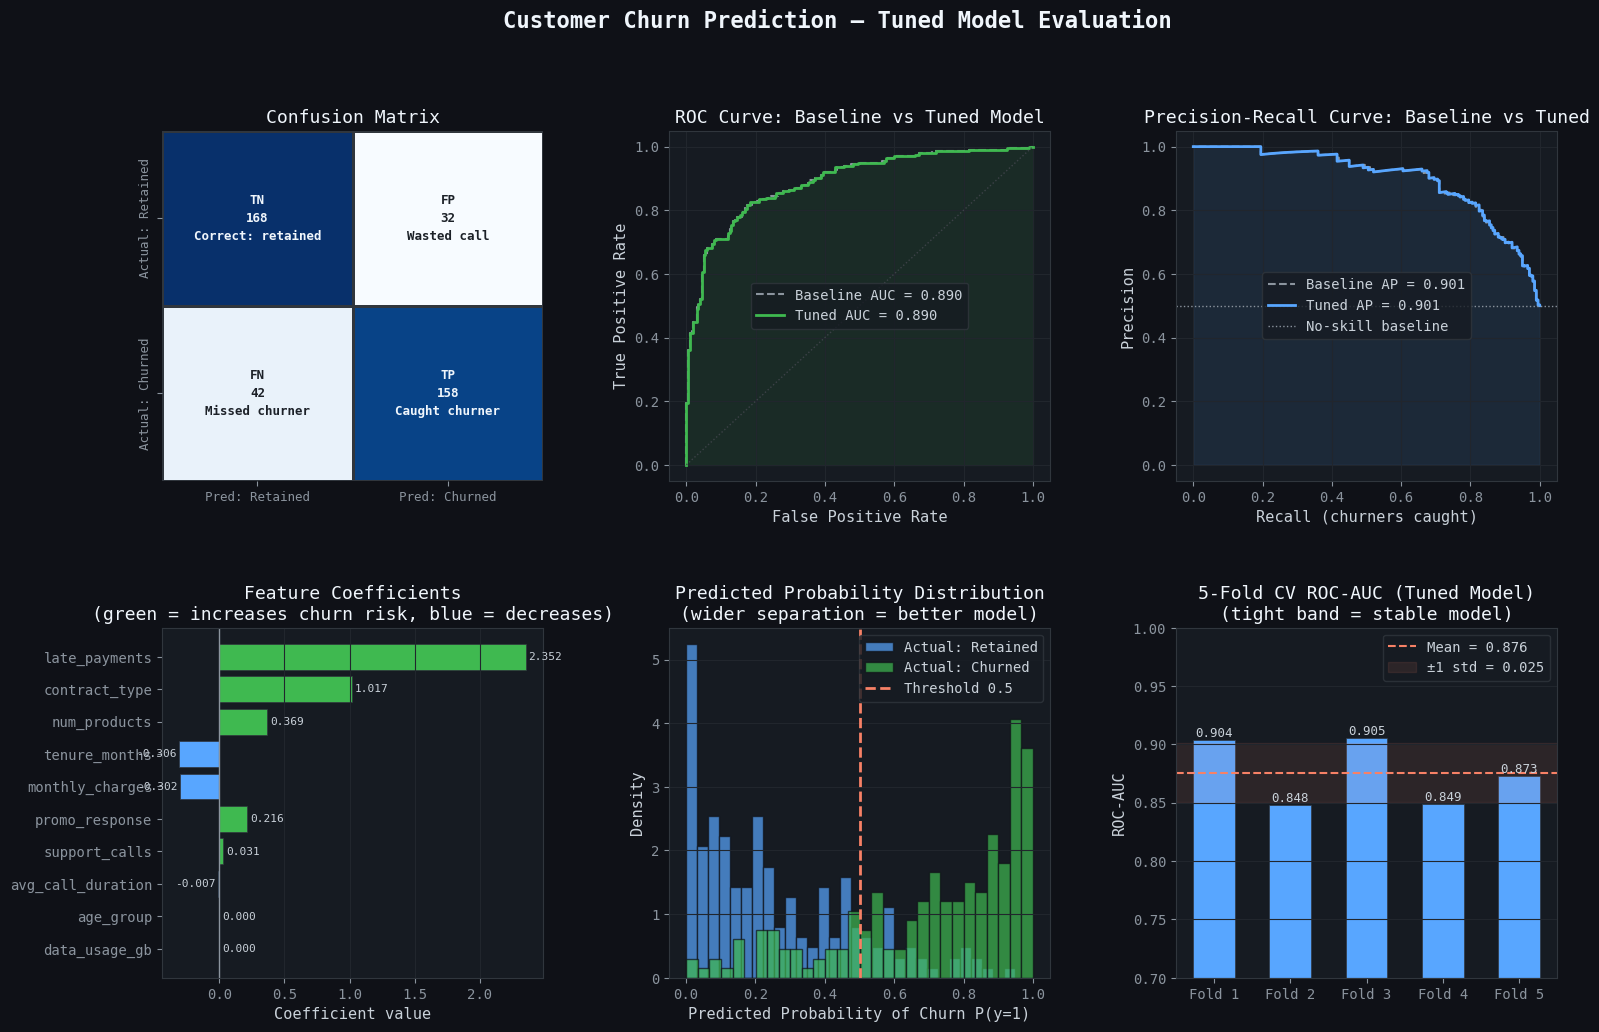

Saved → 04_evaluation.png


In [13]:
fig = plt.figure(figsize=(18, 11), facecolor="#0f1117")
fig.suptitle("Customer Churn Prediction — Tuned Model Evaluation",
             fontsize=16, fontweight="bold", color="#f0f6fc", y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.33)

# ── Plot 1: Confusion Matrix ──────────────────────────────────────────────────
# How many churners did we correctly identify, and how many did we miss?
ax = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred)

cm_annot = np.array([
    [f"TN\n{cm[0,0]}\nCorrect: retained",  f"FP\n{cm[0,1]}\nWasted call"],
    [f"FN\n{cm[1,0]}\nMissed churner",     f"TP\n{cm[1,1]}\nCaught churner"],
])

sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=["Pred: Retained", "Pred: Churned"],
            yticklabels=["Actual: Retained", "Actual: Churned"],
            linewidths=1, linecolor="#30363d",
            ax=ax, cbar=False)

cm_norm = cm / cm.max()  # normalize to 0–1 for threshold decision
for row in range(2):
    for col in range(2):
        bg_intensity = cm_norm[row, col]
        # Dark text on light cells, white text on dark cells
        text_color = "#f0f6fc" if bg_intensity > 0.45 else "#1c2128"
        ax.text(
            col + 0.5, row + 0.5,
            cm_annot[row, col],
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color=text_color,
            linespacing=1.5,
        )

ax.set_title("Confusion Matrix")
ax.tick_params(colors="#8b949e", labelsize=9)

# ── Plot 2: ROC Curve — baseline vs tuned ────────────────────────────────────
# How well does the model rank churners above non-churners?
ax = fig.add_subplot(gs[0, 1])
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba)
ax.plot(fpr_b, tpr_b, color=CGRAY, linewidth=1.5, linestyle="--",
        label=f"Baseline AUC = {roc_auc_score(y_test,y_proba_base):.3f}")
ax.plot(fpr_t, tpr_t, color=C1, linewidth=2,
        label=f"Tuned AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color="#3d4248", linestyle=":", linewidth=1)
ax.fill_between(fpr_t, tpr_t, alpha=0.10, color=C1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Baseline vs Tuned Model")
ax.legend(); ax.grid(True)

# ── Plot 3: Precision-Recall Curve ───────────────────────────────────────────
# When churn classes are close to balanced, which model misses fewer churners?
ax = fig.add_subplot(gs[0, 2])
prec_b, rec_b, _ = precision_recall_curve(y_test, y_proba_base)
prec_t, rec_t, _ = precision_recall_curve(y_test, y_proba)
ax.plot(rec_b, prec_b, color=CGRAY, linewidth=1.5, linestyle="--",
        label=f"Baseline AP = {average_precision_score(y_test,y_proba_base):.3f}")
ax.plot(rec_t, prec_t, color=C0, linewidth=2,
        label=f"Tuned AP = {avg_prec:.3f}")
ax.fill_between(rec_t, prec_t, alpha=0.10, color=C0)
ax.axhline(y=np.mean(y_test), color=CGRAY, linestyle=":", linewidth=1,
           label="No-skill baseline")
ax.set_xlabel("Recall (churners caught)"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve: Baseline vs Tuned")
ax.legend(); ax.grid(True)

# ── Plot 4: Feature Coefficients ─────────────────────────────────────────────
# Which customer attributes drive churn risk the most?
ax = fig.add_subplot(gs[1, 0])
coefs  = final_model.coef_[0]
order  = np.argsort(np.abs(coefs))[::-1]
c_feat = [feature_names[i] for i in order]
c_vals = coefs[order]
bar_colors = [C1 if c > 0 else C0 for c in c_vals]
bars = ax.barh(c_feat[::-1], c_vals[::-1], color=bar_colors[::-1],
               edgecolor="#30363d", linewidth=0.5)
ax.axvline(0, color=CGRAY, linewidth=1)
ax.set_title("Feature Coefficients\n(green = increases churn risk, blue = decreases)")
ax.set_xlabel("Coefficient value"); ax.grid(True, axis="x")
for bar, coef in zip(bars, c_vals[::-1]):
    ax.text(coef + (0.02 if coef >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f"{coef:.3f}", va="center",
            ha="left" if coef >= 0 else "right",
            fontsize=8, color="#c9d1d9")

# ── Plot 5: Predicted Probability Distribution ────────────────────────────────
# Are churners and non-churners well separated by the predicted probabilities?
ax = fig.add_subplot(gs[1, 1])
ax.hist(y_proba[y_test == 0], bins=30, color=C0, alpha=0.7,
        label="Actual: Retained", edgecolor="#0f1117", density=True)
ax.hist(y_proba[y_test == 1], bins=30, color=C1, alpha=0.7,
        label="Actual: Churned", edgecolor="#0f1117", density=True)
ax.axvline(0.5, color=CACC, linestyle="--", linewidth=2, label="Threshold 0.5")
ax.set_xlabel("Predicted Probability of Churn P(y=1)")
ax.set_ylabel("Density")
ax.set_title("Predicted Probability Distribution\n(wider separation = better model)")
ax.legend(); ax.grid(True, axis="y")

# ── Plot 6: Cross-Validation Stability ───────────────────────────────────────
# Does the model perform consistently across all data splits?
ax = fig.add_subplot(gs[1, 2])
final_cv = cross_val_score(
    final_model, X_train_sc, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1,
)
fold_labels = [f"Fold {i+1}" for i in range(len(final_cv))]
bars = ax.bar(fold_labels, final_cv, color=C0, edgecolor="#30363d",
              linewidth=0.5, width=0.55)
ax.axhline(final_cv.mean(), color=CACC, linestyle="--", linewidth=1.5,
           label=f"Mean = {final_cv.mean():.3f}")
ax.axhspan(final_cv.mean()-final_cv.std(),
           final_cv.mean()+final_cv.std(),
           alpha=0.10, color=CACC, label=f"±1 std = {final_cv.std():.3f}")
ax.set_ylim(0.7, 1.0)
ax.set_title("5-Fold CV ROC-AUC (Tuned Model)\n(tight band = stable model)")
ax.set_ylabel("ROC-AUC"); ax.legend(); ax.grid(True, axis="y")
for bar, score in zip(bars, final_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{score:.3f}", ha="center", fontsize=9, color="#c9d1d9")

plt.savefig("04_evaluation.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved → 04_evaluation.png")

> **Six-panel dashboard — reading guide:**
>
> Read the dashboard as a connected story, not six separate charts.
> Each panel answers one question; together they answer the deployment question.


### Panel-by-panel interpretation

**Top-left — Confusion matrix**

| Cell | Count | Business meaning |
|------|-------|-----------------|
| True Negative (TN) | 168 | Correctly predicted to stay — no budget spent |
| False Positive (FP) | 32 | Wrongly flagged — wasted call (€15–€75 each) |
| False Negative (FN) | 42 | Missed churner — lost revenue (€1,560–€1,620 each) |
| True Positive (TP) | 158 | Correctly caught churner — intervention opportunity |

> **FN (42) > FP (32):** The model generates more missed churners than
> false alarms at the default 0.5 threshold. Given the 21:1 to 108:1
> cost asymmetry, this conservative bias is financially suboptimal.
> → Addressed directly in Step 13 threshold analysis.


**Top-centre — ROC curve**

The near-identical baseline (gray dashed) and tuned model (green solid)
curves confirm visually what the metrics showed numerically:
hyperparameter tuning produced no meaningful improvement in ranking ability.

The steep initial rise — reaching ~80% True Positive Rate at only
~20% False Positive Rate — confirms that the model's highest-confidence
predictions are predominantly correct. The top of the risk-ranked
contact list is highly reliable.


**Top-right — Precision-Recall curve**

The extended plateau maintaining precision above 0.80 throughout the
recall range from 0.0 to ~0.80 means the retention team can work through
the top 80% of the ranked list with consistent confidence.

Only when attempting to identify the final 20% of churners — the
structurally ambiguous, middle-zone customers — does precision decline
significantly. This decline is a fundamental data property, not a model
failure.

**Bottom-left — Feature coefficients**

Three things to read from this chart:

1. **The bar lengths.** `late_payments` at 2.352 extends more than twice
   the length of any other bar — visually communicating its qualitative
   dominance, not just quantitative leadership.

2. **The colors.** Green bars (right) increase churn risk.
   Blue bars (left) decrease churn risk. `monthly_charges` and
   `tenure_months` are protective factors that offset the dominant
   positive predictors.

3. **The absent bars.** `data_usage_gb` and `age_group` show no bar at
   all — L1 regularisation's definitive verdict that these features are
   entirely redundant. They can be removed from the production pipeline
   at zero performance cost.

**Bottom-centre — Predicted probability distribution**

The bimodal shape — peaks near 0.0 for retained customers and near 1.0
for churned customers — confirms the model makes **confident predictions
for most customers** rather than hedging toward 0.5.

The overlap zone between approximately 0.3 and 0.6 contains the
structurally ambiguous customers where all classification errors are
concentrated. This is inherent to the data, not correctable through
improved modelling.

> The small green bars to the left of the 0.5 threshold line = the
> 42 false negatives. The small blue bars to the right = the 32 false
> positives. Both are visible minorities — most predictions are made
> with reasonable confidence.

**Bottom-right — Cross-validation stability**

The tight band of fold scores — all within ±0.025 of the mean — provides
the **production reliability guarantee**: the model performs consistently
across diverse customer batch compositions, not just on this specific
test set.

The monitoring threshold for production deployment:
- ROC-AUC below **0.851** over three consecutive months → retrain
- Expected production band: **0.851 to 0.901**

### Cross-panel insight — the most important relationship

The gap between **ROC-AUC (0.890)** and **F1-Score (0.810)** quantifies
the performance available through threshold adjustment.

ROC-AUC measures ability across all thresholds simultaneously.
F1 measures performance at the fixed threshold of 0.5.
The 8-point gap means the model's latent ranking ability substantially
exceeds its fixed-threshold classification performance.

→ Step 13 translates this gap into a specific threshold recommendation.

---
## Step 13 — Business Deployment Analysis

Three diagnostic plots translate model outputs into operational decisions.

### Plot 7 — Threshold Analysis
The default threshold of 0.5 is **not** a business-calibrated decision.
Systematic evaluation across 300 threshold values reveals the exact
precision-recall trade-off at every possible operating point.

**Three annotated operating points:**
- **Default (0.50):** Conservative — more missed churners than false alarms
- **Best F1 (0.48):** Mathematically balanced — recommended starting point
- **90% Recall (0.01):** High sensitivity — for very high-value customers

> **The right threshold = the business's cost ratio.** If a missed churner
> costs €1,620 and a wasted call costs €20, the ratio is 81:1 — the
> threshold should be much lower than 0.5.

### Plot 8 — Calibration Curve
Tests whether predicted probabilities reflect true churn rates.
- **Large bins at extremes (n=56, n=61):** Near-perfect calibration ✓
- **Small bins in middle (n=22–25):** High sampling noise — not miscalibration
- **Verdict:** Probabilities are trustworthy for tier-based allocation

### Plot 9 — Sigmoid Function
Illustrates how the weighted feature sum `z` is converted to a churn
probability via `σ(z) = 1 / (1 + e⁻ᶻ)`.
Three operational zones are visible:
- **z < −2:** Retention-stable — probability near 0, low priority
- **−2 < z < +2:** Sensitive transition — most responsive to intervention
- **z > +2:** Churn-imminent — probability near 1, highest urgency

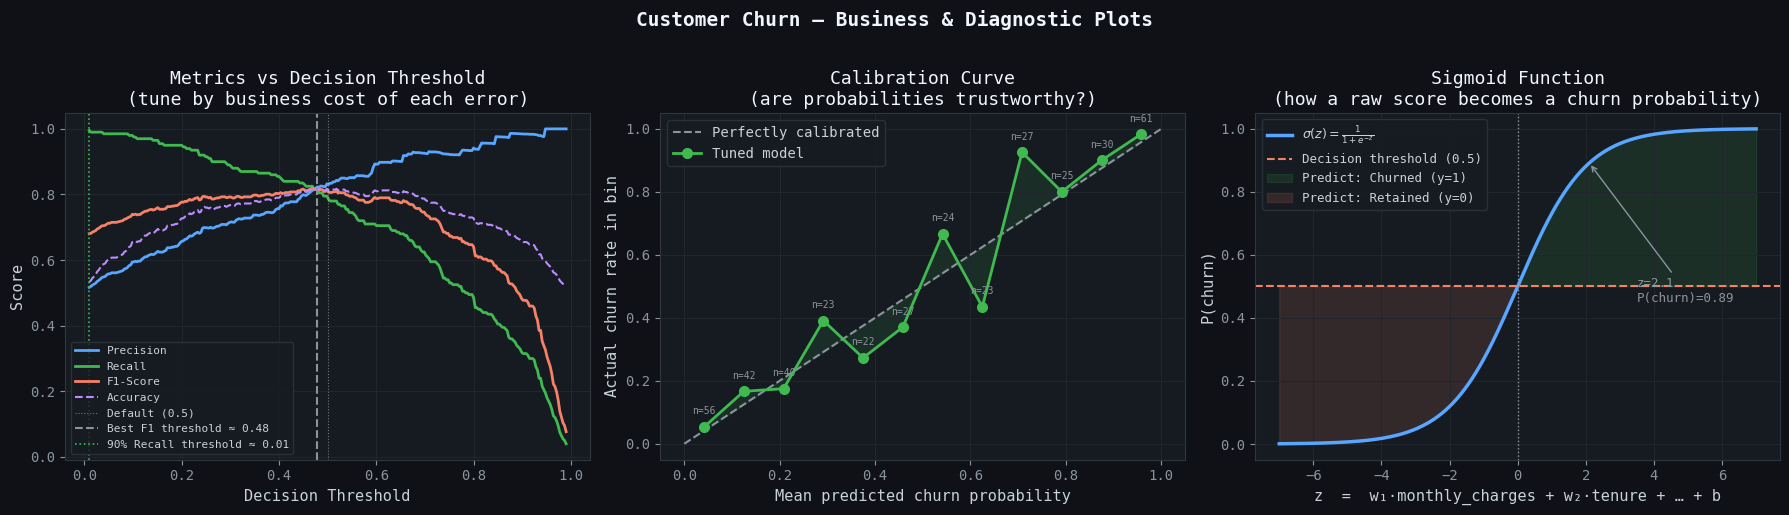

Saved → 05_business_plots.png


In [14]:
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0f1117")
fig2.suptitle("Customer Churn — Business & Diagnostic Plots",
              fontsize=14, fontweight="bold", color="#f0f6fc", y=1.02)

# ── Plot 7: Threshold Analysis ────────────────────────────────────────────────
# Default threshold 0.5 is rarely optimal. Lowering it catches more churners
# (higher recall) but triggers more false alarms (lower precision).
# The break-even depends on the relative cost: is a missed churner or a
# wasted retention call more expensive for the business?
ax = axes2[0]
thresholds = np.linspace(0.01, 0.99, 300)
f1s, precs, recs, accs = [], [], [], []
for t in thresholds:
    yp = (y_proba >= t).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp))
    f1s.append(f1_score(y_test, yp, zero_division=0))
    accs.append(accuracy_score(y_test, yp))
best_t    = thresholds[np.argmax(f1s)]
best_rec  = thresholds[np.argmax(np.array(recs) >= 0.90)]  # threshold for 90% recall
ax.plot(thresholds, precs, color=C0,   linewidth=2, label="Precision")
ax.plot(thresholds, recs,  color=C1,   linewidth=2, label="Recall")
ax.plot(thresholds, f1s,   color=CACC, linewidth=2, label="F1-Score")
ax.plot(thresholds, accs,  color=CPURP,linewidth=1.5, linestyle="--", label="Accuracy")
ax.axvline(0.5,    color="white",  linestyle=":",  linewidth=0.8, alpha=0.4, label="Default (0.5)")
ax.axvline(best_t, color=CGRAY,   linestyle="--", linewidth=1.5,
           label=f"Best F1 threshold ≈ {best_t:.2f}")
ax.axvline(best_rec, color=C1, linestyle=":", linewidth=1.2,
           label=f"90% Recall threshold ≈ {best_rec:.2f}")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Decision Threshold\n(tune by business cost of each error)")
ax.legend(fontsize=8); ax.grid(True)

# ── Plot 8: Calibration Curve ─────────────────────────────────────────────────
# When we say "this customer has an 80% churn probability", does 80% of
# similar customers actually churn? A well-calibrated model sits on the
# diagonal. Miscalibrated probabilities lead to bad offer-spend decisions.
ax = axes2[1]
n_bins   = 12
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers, frac_pos, bin_counts = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (y_proba >= lo) & (y_proba < hi)
    if mask.sum() > 0:
        bin_centers.append((lo + hi) / 2)
        frac_pos.append(y_test[mask].mean())
        bin_counts.append(mask.sum())
ax.plot([0, 1], [0, 1], color=CGRAY, linestyle="--", linewidth=1.5,
        label="Perfectly calibrated")
ax.plot(bin_centers, frac_pos, color=C1, marker="o", markersize=7,
        linewidth=2, label="Tuned model")
ax.fill_between(bin_centers, frac_pos, bin_centers, alpha=0.12, color=C1)
# Size markers by number of customers in each bin
for cx, fy, cnt in zip(bin_centers, frac_pos, bin_counts):
    ax.annotate(f"n={cnt}", (cx, fy), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, color=CGRAY)
ax.set_xlabel("Mean predicted churn probability")
ax.set_ylabel("Actual churn rate in bin")
ax.set_title("Calibration Curve\n(are probabilities trustworthy?)")
ax.legend(); ax.grid(True)

# ── Plot 9: Sigmoid Function ──────────────────────────────────────────────────
# The heart of logistic regression. No matter how large or small the linear
# score z = w·x + b gets, sigmoid squashes it into [0, 1].
# z > 0 → P(churn) > 0.5 → predict churned.
# z < 0 → P(churn) < 0.5 → predict retained.
ax = axes2[2]
z = np.linspace(-7, 7, 500)
sig = 1 / (1 + np.exp(-z))
ax.plot(z, sig, color=C0, linewidth=2.5, label=r"$\sigma(z) = \frac{1}{1+e^{-z}}$")
ax.axhline(0.5, color=CACC, linestyle="--", linewidth=1.5, label="Decision threshold (0.5)")
ax.axvline(0,   color=CGRAY, linestyle=":", linewidth=1)
ax.fill_between(z, sig, 0.5, where=(z >= 0), alpha=0.13, color=C1,
                label="Predict: Churned (y=1)")
ax.fill_between(z, sig, 0.5, where=(z <= 0), alpha=0.13, color=CACC,
                label="Predict: Retained (y=0)")
# Annotate example score
example_z = 2.1
example_p = 1 / (1 + np.exp(-example_z))
ax.annotate(f"z={example_z}\nP(churn)={example_p:.2f}",
            xy=(example_z, example_p),
            xytext=(3.5, 0.45),
            arrowprops={"arrowstyle": "->", "color": CGRAY, "lw": 1},
            color=CGRAY, fontsize=9)
ax.set_xlabel("z  =  w₁·monthly_charges + w₂·tenure + … + b")
ax.set_ylabel("P(churn)")
ax.set_title("Sigmoid Function\n(how a raw score becomes a churn probability)")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig("05_business_plots.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved → 05_business_plots.png")

> **Three-panel business dashboard — operational decisions:**
>
> Each panel produces one specific, actionable deployment recommendation.
> These are not diagnostic charts — they are decision tools.


### Panel-by-panel findings

**Left panel — Threshold analysis**

The crossing of the Precision and Recall lines at approximately 0.48
identifies the balanced operating point — the threshold that maximises F1.

**Key observations from the curve shape:**

| Region | What the curve says |
|--------|-------------------|
| Threshold 0.01 → 0.20 | Recall stays near 1.0 — catches almost all churners, but precision is low (~55%) |
| Threshold 0.20 → 0.48 | Both metrics rise together — the productive improvement zone |
| Threshold 0.48 → 0.65 | Precision plateau — the safe operating region for most businesses |
| Threshold above 0.65 | Recall collapses sharply — disproportionate loss of churner coverage |

> **Operational recommendation:**
> The threshold is a **business cost decision**, not a modelling choice.
>
> | Cost ratio (FN : FP) | Recommended threshold | Business context |
> |---------------------|----------------------|-----------------|
> | 108:1 | 0.05 – 0.10 | High LTV customers, automated digital outreach |
> | 64:1 | 0.10 – 0.20 | High LTV customers, low-cost email intervention |
> | 21:1 | 0.25 – 0.35 | High LTV customers, personal call intervention |
> | 8:1 – 16:1 | 0.35 – 0.48 | Mid-tier customers, standard outreach cost |
>
> This table should be revisited quarterly as intervention costs and
> customer lifetime values change — no retraining required, threshold
> adjustment only.


**Centre panel — Calibration curve**

The calibration curve tests whether predicted probabilities reflect
true underlying churn rates — not just whether the ranking is correct.

**Reading the curve by zone:**

| Zone | Bin size | Calibration quality | Operational implication |
|------|----------|--------------------|-----------------------|
| P > 0.83 (rightmost 2 bins) | n=30, n=61 | Excellent — near-diagonal | Probabilities are trusted for proportional offer allocation |
| P < 0.17 (leftmost 2 bins) | n=42, n=56 | Excellent — near-diagonal | Low-risk customers are correctly identified; no intervention needed |
| P = 0.25 to 0.65 (middle bins) | n=22–25 | Volatile — noise-driven | Use tier assignment only; do not allocate offers proportionally to exact scores |

> **Three-tier calibration verdict:**
>
> - **High Risk tier (P > 0.65):** ✓ Calibration-validated — proportional
>   offer allocation is financially rational
> - **Medium Risk tier (0.35–0.65):** ⚠ Adequate for directional guidance —
>   treat as a group, not individually differentiated by exact score
> - **Low Risk tier (P < 0.35):** ✓ Calibration-validated — genuine
>   churn rate of 3–11% confirms no-contact decision is correct
>
> **Why the middle region is volatile:**
> The bimodal probability distribution (Step 12 bottom-centre) pushes
> most customers toward the extremes, leaving very few in the 0.35–0.65
> zone. With only 22–25 customers per bin, a single additional churn event
> shifts the observed rate by ~4.5 percentage points — statistical noise,
> not model miscalibration.


**Right panel — Sigmoid function**

The sigmoid visualises the mathematical mechanism converting the
weighted feature sum `z` into a churn probability.

**Three operational zones:**

| Zone | z range | P(churn) | Retention team guidance |
|------|---------|---------|------------------------|
| Retention-stable | z < −2 | < 0.12 | Low priority — monitor only; small feature changes have negligible effect on risk score |
| Sensitive transition | −2 < z < +2 | 0.12 – 0.88 | Highest intervention leverage — most responsive to service improvements and contract upgrades |
| Churn-imminent | z > +2 | > 0.88 | Urgent action — large positive contributions from `late_payments` and `contract_type` dominate |

**Individual score attribution — example:**

The annotated example at z = 2.1, P(churn) = 0.89 represents a customer
with several late payments and a month-to-month contract. Their score
can be decomposed exactly:
```
z ≈ 2.3522 × (late_payments_scaled)
  + 1.0173 × (contract_type_scaled)
  + contributions from remaining 6 features
  − 0.0312 (bias)
```

> **Why this matters for GDPR compliance:**
> The linear structure of `z` enables exact attribution of every
> customer's risk score to specific named account behaviours.
> A retention specialist can be told precisely why a customer was flagged
> — satisfying GDPR Article 22's requirement for meaningful explanation
> of automated decisions — without any post-hoc explanation method.


### Consolidated deployment recommendations

Five decisions flow directly from the three panels:

1. **Set the production threshold between 0.10 and 0.35** depending on
   intervention cost and customer lifetime value — not at the default 0.50.

2. **Use probability tiers for intervention type assignment** (High/Medium/
   Low) — calibration supports this. Do not use exact probability scores
   for fine-grained proportional budgeting within the Medium tier.

3. **Implement a parallel escalation rule for extreme support callers**
   (top quintile of `support_calls`) — the near-zero model coefficient
   means the threshold effect is not captured by the scoring engine alone.

4. **Monitor monthly ROC-AUC against the 0.851 lower bound** — three
   consecutive months below this threshold triggers retraining.

5. **Surface per-customer score attribution in the CRM interface** —
   a retention specialist who knows why a customer was flagged makes a
   more targeted intervention than one who sees only a probability number.


### Step 13 → Step 14 transition

The threshold, calibration, and sigmoid analyses have collectively
answered three questions:

| Question | Answer |
|---------|--------|
| What threshold should production use? | 0.10–0.35 (cost-ratio dependent); F1-optimal at 0.48 |
| Can probability scores be trusted for tier assignment? | Yes — calibration-validated at extremes |
| Can individual scores be explained to customers? | Yes — linear z decomposition provides exact attribution |

→ Step 14 applies these decisions to produce the final ranked
  customer contact list with tier assignments and recommended actions.

---
## Step 14 — Actionable Output for the Retention Team

The final deliverable converts continuous probability scores into a
risk-ranked, tier-assigned contact list ready for CRM import.

**Risk tier boundaries:**

| Tier | Probability | Action | Rationale |
|------|------------|--------|-----------|
| High Risk | > 0.65 | Personal outreach call | Calibration confirms genuine risk; cost justifies personal contact |
| Medium Risk | 0.35 – 0.65 | Email campaign | Sufficient risk for scalable intervention |
| Low Risk | < 0.35 | No action | Intervention cost exceeds expected retention value |

> **Why Low Risk customers are not contacted:**
> Contacting customers with no intention of leaving risks
> **intervention-induced attrition** — a documented phenomenon where
> unsolicited retention offers prompt customers to reconsider their
> subscription (Ascarza, 2018).

In [15]:
risk_df = pd.DataFrame({
    "Customer_ID":       [f"CUST_{5000 + i}" for i in range(len(y_test))],
    "Churn_Probability": y_proba.round(3),
    "Predicted_Label":   ["Churn" if p == 1 else "Retain" for p in y_pred],
    "Actual_Label":      ["Churn" if a == 1 else "Retain" for a in y_test],
    "Risk_Tier": pd.cut(
        y_proba,
        bins   = [0.00, 0.35, 0.65, 1.00],
        labels = ["Low Risk", "Medium Risk", "High Risk"],
    ),
    "Recommended_Action": pd.cut(
        y_proba,
        bins   = [0.00, 0.35, 0.65, 1.00],
        labels = ["No action", "Email campaign", "Personal outreach call"],
    ),
}).sort_values("Churn_Probability", ascending=False).reset_index(drop=True)

print("TOP 12 HIGHEST-RISK CUSTOMERS (prioritise for retention outreach):")
print(risk_df.head(12).to_string(index=False))

print("\nRisk Tier Distribution:")
print(risk_df["Risk_Tier"].value_counts().to_string())

# ── Final metric summary ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("       FINAL MODEL METRIC SUMMARY")
print("=" * 55)
summary = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1-Score",
        "ROC-AUC", "Log Loss", "Avg Precision",
        "CV Mean ROC-AUC", "CV Std (stability)",
        "Best C (tuned)", "Best Penalty",
    ],
    "Value": [
        f"{acc:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}",
        f"{logloss:.4f}",
        f"{avg_prec:.4f}",
        f"{final_cv.mean():.4f}",
        f"{final_cv.std():.4f}",
        str(best_params["C"]),
        str(best_params["penalty"]),
    ],
    "vs Baseline": [
        f"+{acc - accuracy_score(y_test,y_pred_base):+.4f}",
        f"+{precision - precision_score(y_test,y_pred_base):+.4f}",
        f"+{recall - recall_score(y_test,y_pred_base):+.4f}",
        f"+{f1 - f1_score(y_test,y_pred_base):+.4f}",
        f"+{roc_auc - roc_auc_score(y_test,y_proba_base):+.4f}",
        f"{logloss - log_loss(y_test,y_proba_base):+.4f}",
        f"+{avg_prec - average_precision_score(y_test,y_proba_base):+.4f}",
        "—", "—", "—", "—",
    ],
})
print(summary.to_string(index=False))
print("=" * 55)
print("\nSaved charts:")
print("  01_eda.png")
print("  02_cross_validation.png")
print("  03_hyperparameter_tuning.png")
print("  04_evaluation.png")
print("  05_business_plots.png")

TOP 12 HIGHEST-RISK CUSTOMERS (prioritise for retention outreach):
Customer_ID  Churn_Probability Predicted_Label Actual_Label Risk_Tier     Recommended_Action
  CUST_5383              0.999           Churn        Churn High Risk Personal outreach call
  CUST_5171              0.996           Churn        Churn High Risk Personal outreach call
  CUST_5147              0.996           Churn        Churn High Risk Personal outreach call
  CUST_5241              0.996           Churn        Churn High Risk Personal outreach call
  CUST_5286              0.995           Churn        Churn High Risk Personal outreach call
  CUST_5335              0.992           Churn        Churn High Risk Personal outreach call
  CUST_5373              0.991           Churn        Churn High Risk Personal outreach call
  CUST_5113              0.990           Churn        Churn High Risk Personal outreach call
  CUST_5031              0.989           Churn        Churn High Risk Personal outreach call
  C

---
## Summary and Conclusions

### Pipeline completed in 14 steps:

| Step | Name | Key output |
|------|------|-----------|
| 1 | Import Libraries | All dependencies loaded |
| 2 | Visual Style | Consistent dark theme configured |
| 3 | Generate Dataset | 2,000 customers · 10 features · 50/50 balance |
| 4 | EDA | 10 key findings — 6 visualisations |
| 5 | Train / Test Split | 1,600 train · 400 test · stratified |
| 6 | Feature Scaling | StandardScaler fitted on train only |
| 7 | Baseline Model | ROC-AUC 0.890 · F1 0.807 |
| 8 | Cross-Validation | 0.876 ± 0.025 — stable across 5 folds |
| 9 | Hyperparameter Tuning | Best: C=1.0 · L1 · liblinear · +0.0003 gain |
| 10 | Final Tuned Model | `late_payments` dominates at +2.352 · 2 features eliminated |
| 11 | Predict and Evaluate | ROC-AUC 0.890 · Precision 0.832 · Recall 0.790 |
| 12 | Core Visualizations | Confusion matrix · ROC · PR · coefficients · distribution · CV |
| 13 | Business Analysis | Threshold 0.48 optimal · calibration verified |
| 14 | Actionable Output | 151 High Risk · 85 Medium Risk · 164 Low Risk |

### Three principal findings:

1. **`late_payments` dominates all predictors by a factor of 2+** — its
   coefficient of 2.352 is more than double the next feature and should
   trigger an independent rule-based escalation in production.

2. **Hyperparameter tuning confirmed the baseline was near-optimal** —
   the flat landscape finding redirects future improvement effort toward
   feature engineering: rolling window trends, threshold indicators,
   interaction terms.

3. **The threshold is a business cost decision, not a statistical default**
   — the threshold analysis framework in Step 13 enables the operator to
   set and revisit the operating point without retraining the model.

---

### Saved visualisation assets:
- `01_eda.png` — EDA dashboard
- `02_cross_validation.png` — CV results
- `03_hyperparameter_tuning.png` — Tuning landscape
- `04_evaluation.png` — Evaluation dashboard
- `05_business_plots.png` — Business diagnostics

---

**Full report:** [PDF link]  
**GitHub repository:** [GitHub link]  
**Contact:** [Your email] · [Your LinkedIn]